In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [4]:
df= pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'],inplace = True)

In [7]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [12]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         148
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

<Axes: ylabel='Density'>

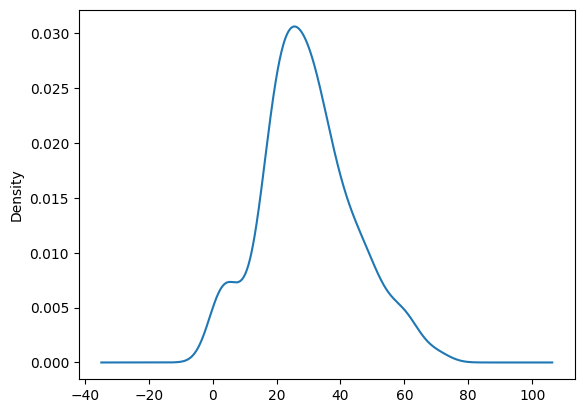

In [15]:
X_train["Age"].plot(kind= "kde")

In [13]:
from sklearn.compose import ColumnTransformer

In [20]:
trf = ColumnTransformer(transformers  = [
("one" , SimpleImputer(strategy ="mean" ) , ["Age"]),
("two" , SimpleImputer(strategy = "most_frequent") , ["Embarked"]),
("three",OneHotEncoder(drop = "first" , sparse_output = False) ,["Embarked" ,"Sex"])
 ], remainder = "passthrough")

In [21]:
trf.fit(X_train)
X_trained = trf.transform(X_train)
X_tested = trf.transform(X_test)

In [38]:
X_trained.columns

Index(['one__Age', 'two__Embarked', 'three__Embarked_Q', 'three__Embarked_S',
       'three__Embarked_nan', 'three__Sex_male', 'remainder__Pclass',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare'],
      dtype='str')

In [39]:
X_trained = pd.DataFrame(X_trained , columns = trf.get_feature_names_out())
X_trained.drop(columns = ["two__Embarked"],inplace = True) 

<Axes: ylabel='Density'>

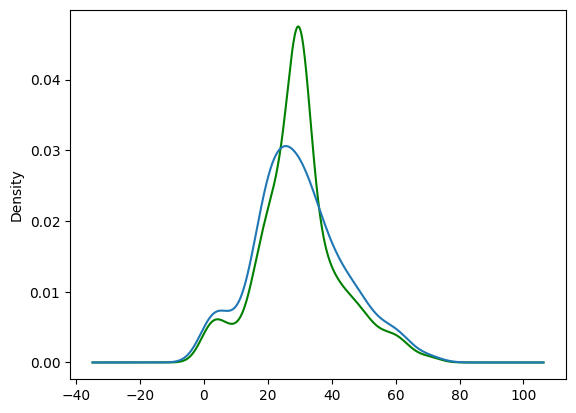

In [32]:
X_trained["one__Age"].plot(kind = "kde", color = "green")
X_train["Age"].plot(kind = "kde")

In [43]:
X_tested = trf.transform(X_test)

In [57]:
Model  = LogisticRegression(max_iter=1000)

In [50]:
X_tested = pd.DataFrame(X_tested, columns=trf.get_feature_names_out(), index=X_test.index)

In [54]:
X_tested.drop(columns = ["two__Embarked"], inplace = True)

In [58]:
from sklearn.metrics import accuracy_score
Model.fit(X_trained , y_train)
y_pred = Model.predict(X_tested)

accuracy_score(y_test , y_pred)

0.7877094972067039